<a href="https://colab.research.google.com/github/ajinfajrian/DataScience_240401020100_Fajrian/blob/master/Pertemuan13_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Fajrian Ichlasul Maruto \
**NIM:** 240401020100 \
**Kelas:** IF401 \
**Mata Kuliah:** Data Science \
**Pertemuan 13:** Pengantar Deep Learning & NLP Dasar

### Deep Learning (ANN) - Eksplorasi Data Non-Linear

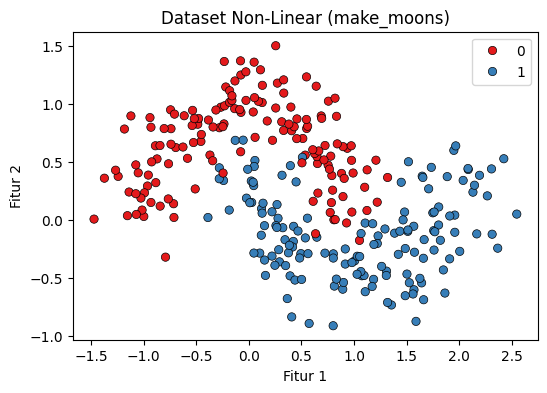

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generate Data Non-Linear (300 titik, 2 kelas)
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# 2. Visualisasi Data
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1], hue=y_moons, palette='Set1', edgecolor='k')
plt.title("Dataset Non-Linear (make_moons)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

# 3. Preprocessing (Standarisasi dan Splitting)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

### Deep Learning (ANN) - Implementasi Neural Network dengan Keras

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Membangun Arsitektur Neural Network (Sequential)
model_ann = Sequential([
    Input(shape=(2,)),                              # <-- Menggunakan objek Input terpisah
    Dense(16, activation='relu'),                   # Hidden layer pertama (16 neuron)
    Dense(8, activation='relu'),                    # Hidden layer kedua (8 neuron)
    Dense(1, activation='sigmoid')                  # Output layer (1 neuron)
])

# 2. Kompilasi Model
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Melatih Model (Proses belajar/fit)
print("Melatih model Artificial Neural Network...")
history = model_ann.fit(X_train_scaled, y_train_m, epochs=50, validation_split=0.2, verbose=0)

# 4. Evaluasi Model pada Data Uji
loss, accuracy = model_ann.evaluate(X_test_scaled, y_test_m, verbose=0)
print(f"Akurasi Model Deep Learning pada data pengujian: {accuracy * 100:.2f}%\n")

Melatih model Artificial Neural Network...
Akurasi Model Deep Learning pada data pengujian: 90.00%



### NLP Dasar - TF-IDF dan Sentimen Analisis

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Generate 40 Ulasan Produk Sintetis Berbahasa Indonesia (Positif/Negatif berselang-seling)
ulasan = [
    "Produk ini sangat bagus dan berkualitas!", "Kecewa, barang cepat rusak.",
    "Pengiriman cepat, packing rapi, mantap.", "Tidak sesuai deskripsi, jelek.",
    "Sangat puas belanja di sini.", "Pelayanan buruk, respon lambat.",
    "Bahan tebal dan nyaman dipakai.", "Warna luntur saat dicuci pertama kali.",
    "Harga murah tapi kualitas oke banget.", "Sayang sekali ukurannya kekecilan.",
    "Recommended seller, pasti beli lagi.", "Barang cacat dikirim, rugi.",
    "Suka banget sama desainnya, elegan.", "Baterai cepat habis, tidak awet.",
    "Fungsi normal semua, terima kasih.", "Tombol agak keras, kurang nyaman.",
    "Sangat membantu pekerjaan saya sehari-hari.", "Aplikasi sering error dan keluar sendiri.",
    "Packing super aman pakai bubble wrap tebal.", "Pengiriman lama sekali, seminggu baru sampai.",
    "Kualitas suara jernih, bass terasa.", "Kamera blur, tidak sesuai ekspektasi.",
    "Bahan premium, jahitan rapi.", "Layar retak saat diterima, parah.",
    "Admin ramah dan sangat membantu.", "Proses refund berbelit-belit.",
    "Anak saya sangat suka mainannya.", "Bahan panas dan gatal di kulit.",
    "Bakal jadi langganan terus nih.", "Uang terbuang sia-sia beli ini.",
    "Toko amanah, sukses selalu.", "Barang KW, padahal bilangnya ori.",
    "Fitur lengkap dan mudah digunakan.", "Sinyal sering hilang, kurang stabil.",
    "Sangat praktis dibawa kemana-mana.", "Berat dan desainnya terlalu jadul.",
    "Puas banget, bintang 5 pokoknya!", "Kapok belanja di toko ini lagi.",
    "Expired date masih lama, aman.", "Rasanya aneh, tidak enak sama sekali."
]

# Label: 1 (Positif), 0 (Negatif)
label = [1, 0] * 20

df_nlp = pd.DataFrame({'Ulasan': ulasan, 'Sentimen': label})
display(df_nlp.head())

# 2. Ekstraksi Fitur Teks menggunakan TF-IDF
tfidf = TfidfVectorizer()
X_teks = tfidf.fit_transform(df_nlp['Ulasan'])
y_teks = df_nlp['Sentimen']

# 3. Latih model Machine Learning sederhana (Logistic Regression) untuk klasifikasi teks
model_nlp = LogisticRegression()
model_nlp.fit(X_teks, y_teks)

# 4. Uji Coba Prediksi Teks Baru
teks_baru = [
    "Kualitas barangnya luar biasa, saya sangat puas!",
    "Sangat mengecewakan, barang tidak berfungsi."
]
teks_baru_tfidf = tfidf.transform(teks_baru)
prediksi_baru = model_nlp.predict(teks_baru_tfidf)

print("\n--- Hasil Prediksi Analisis Sentimen Baru ---")
for teks, pred in zip(teks_baru, prediksi_baru):
    hasil = "Positif" if pred == 1 else "Negatif"
    print(f"Kalimat: '{teks}' --> Sentimen: {hasil}")

,Ulasan,Sentimen
0,Produk ini sangat bagus dan berkualitas!,1
1,"Kecewa, barang cepat rusak.",0
2,"Pengiriman cepat, packing rapi, mantap.",1
3,"Tidak sesuai deskripsi, jelek.",0
4,Sangat puas belanja di sini.,1



--- Hasil Prediksi Analisis Sentimen Baru ---
Kalimat: 'Kualitas barangnya luar biasa, saya sangat puas!' --> Sentimen: Positif
Kalimat: 'Sangat mengecewakan, barang tidak berfungsi.' --> Sentimen: Negatif


### Kesimpulan Pertemuan 13
* **Deep Learning (ANN):** Dengan menggunakan arsitektur Keras (`Sequential`, `Dense`), Neural Network mampu membedakan data yang kompleks dan tidak bisa dipisahkan secara linear (seperti dataset `make_moons`) melalui pembaruan bobot (iterasi *epochs*) pada *hidden layer*.
* **Natural Language Processing (NLP):** Komputer tidak memahami teks secara langsung. Menggunakan ekstraksi TF-IDF, kata-kata dalam bahasa Indonesia berhasil direpresentasikan menjadi matriks angka. Model regresi sederhana kemudian sukses memprediksi sentimen ulasan (positif atau negatif) dari pelanggan dengan cukup akurat.